## Imports

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense
from keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Pre-processing

In [2]:
d = pd.read_csv("/Users/divyankshah/Documents/Jupyter NB/Mini Project/Crop_recommendation.csv")

In [3]:
d.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
output = {
    "rice" : 1,
    "maize": 2,
    "chickpea": 3,
    "kidneybeans": 4,
    "pigeonpeas": 5,
    "mothbeans": 6,
    "mungbean": 7,
    "blackgram": 8,
    "lentil": 9,
    "pomegranate": 10,
    "banana": 11,
    "mango": 12,
    "grapes": 13,
    "watermelon": 14,
    "muskmelon": 15,
    "apple": 16,
    "orange": 17,
    "papaya": 18,
    "coconut": 19,
    "cotton": 20,
    "jute": 21,
    "coffee": 22
}

In [5]:
l = []

for i in d['label']:
#     print(i)
    l.append(output.get(i))

In [6]:
outputArray = np.array(l)

In [7]:
d['Output'] = outputArray

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(d[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']],
                                                  d.Output,test_size=0.2, random_state=25)


In [9]:
scalerX = MinMaxScaler()
print(scalerX.fit(X_train))

MinMaxScaler()


In [10]:
x_train_scaled = scalerX.transform(X_train)
x_train_np = np.asarray(x_train_scaled)
type(x_train_np)

numpy.ndarray

In [11]:
x_test_scaled = scalerX.transform(X_test)
x_test_np = np.asarray(x_test_scaled)
type(x_test_np)

numpy.ndarray

In [12]:
d.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Output
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1


In [13]:
d.drop('label', axis='columns')

,N,P,K,temperature,humidity,ph,rainfall,Output
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,22
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,22
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,22
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,22


In [85]:
d.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Output
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1


## Model Building

In [62]:
from keras import regularizers
model = Sequential()
model.add(Dense(100, input_dim = 7, activation='relu', kernel_initializer='ones', 
                bias_initializer='zeros', kernel_regularizer = regularizers.l2(0.001)))
model.add(Dense(75, activation='sigmoid'))
model.add(Dense(50, activation='sigmoid'))
model.add(Dense(23, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

m = model.fit(x_train_np, y_train,validation_data=(x_test_np, y_test), epochs=700, verbose = 1)

Train on 1760 samples, validate on 440 samples
Epoch 1/700
1760/1760 [==============================] - 1s 634us/step - loss: 3.8073 - accuracy: 0.0466 - val_loss: 3.7299 - val_accuracy: 0.0432
Epoch 2/700
1760/1760 [==============================] - 0s 158us/step - loss: 3.6829 - accuracy: 0.0716 - val_loss: 3.6416 - val_accuracy: 0.0909
Epoch 3/700
1760/1760 [==============================] - 0s 150us/step - loss: 3.6005 - accuracy: 0.0915 - val_loss: 3.5557 - val_accuracy: 0.0818
Epoch 4/700
1760/1760 [==============================] - 0s 153us/step - loss: 3.5140 - accuracy: 0.1136 - val_loss: 3.4758 - val_accuracy: 0.0909
Epoch 5/700
1760/1760 [==============================] - 0s 159us/step - loss: 3.4263 - accuracy: 0.1057 - val_loss: 3.3893 - val_accuracy: 0.0591
Epoch 6/700
1760/1760 [==============================] - 0s 157us/step - loss: 3.3297 - accuracy: 0.1239 - val_loss: 3.2782 - val_accuracy: 0.0864
Epoch 7/700
1760/1760 [==============================] - 0s 183us/step 

1760/1760 [==============================] - 0s 148us/step - loss: 1.0714 - accuracy: 0.6682 - val_loss: 1.0885 - val_accuracy: 0.6295
Epoch 57/700
1760/1760 [==============================] - 0s 146us/step - loss: 1.0399 - accuracy: 0.6670 - val_loss: 1.0634 - val_accuracy: 0.6455
Epoch 58/700
1760/1760 [==============================] - 0s 146us/step - loss: 1.0138 - accuracy: 0.6847 - val_loss: 1.0257 - val_accuracy: 0.6614
Epoch 59/700
1760/1760 [==============================] - 0s 148us/step - loss: 0.9839 - accuracy: 0.6881 - val_loss: 1.0055 - val_accuracy: 0.6864
Epoch 60/700
1760/1760 [==============================] - 0s 146us/step - loss: 0.9635 - accuracy: 0.7102 - val_loss: 0.9793 - val_accuracy: 0.7159
Epoch 61/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.9319 - accuracy: 0.7330 - val_loss: 0.9403 - val_accuracy: 0.7273
Epoch 62/700
1760/1760 [==============================] - 0s 151us/step - loss: 0.9058 - accuracy: 0.7415 - val_loss: 0.9166 

1760/1760 [==============================] - 0s 147us/step - loss: 0.2921 - accuracy: 0.9392 - val_loss: 0.3070 - val_accuracy: 0.9295
Epoch 112/700
1760/1760 [==============================] - 0s 148us/step - loss: 0.2875 - accuracy: 0.9420 - val_loss: 0.3515 - val_accuracy: 0.8841
Epoch 113/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.2881 - accuracy: 0.9347 - val_loss: 0.3027 - val_accuracy: 0.9273
Epoch 114/700
1760/1760 [==============================] - 0s 148us/step - loss: 0.2746 - accuracy: 0.9477 - val_loss: 0.3018 - val_accuracy: 0.9205
Epoch 115/700
1760/1760 [==============================] - 0s 146us/step - loss: 0.2731 - accuracy: 0.9432 - val_loss: 0.2871 - val_accuracy: 0.9386
Epoch 116/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.2688 - accuracy: 0.9432 - val_loss: 0.2843 - val_accuracy: 0.9295
Epoch 117/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.2611 - accuracy: 0.9466 - val_loss: 0

1760/1760 [==============================] - 0s 151us/step - loss: 0.1278 - accuracy: 0.9830 - val_loss: 0.1516 - val_accuracy: 0.9727
Epoch 167/700
1760/1760 [==============================] - 0s 151us/step - loss: 0.1278 - accuracy: 0.9824 - val_loss: 0.1618 - val_accuracy: 0.9614
Epoch 168/700
1760/1760 [==============================] - 0s 154us/step - loss: 0.1300 - accuracy: 0.9847 - val_loss: 0.1527 - val_accuracy: 0.9682
Epoch 169/700
1760/1760 [==============================] - 0s 150us/step - loss: 0.1397 - accuracy: 0.9756 - val_loss: 0.1541 - val_accuracy: 0.9614
Epoch 170/700
1760/1760 [==============================] - 0s 150us/step - loss: 0.1290 - accuracy: 0.9812 - val_loss: 0.1535 - val_accuracy: 0.9636
Epoch 171/700
1760/1760 [==============================] - 0s 148us/step - loss: 0.1241 - accuracy: 0.9841 - val_loss: 0.1430 - val_accuracy: 0.9659
Epoch 172/700
1760/1760 [==============================] - 0s 168us/step - loss: 0.1206 - accuracy: 0.9818 - val_loss: 0

1760/1760 [==============================] - 0s 145us/step - loss: 0.0875 - accuracy: 0.9858 - val_loss: 0.1457 - val_accuracy: 0.9591
Epoch 222/700
1760/1760 [==============================] - 0s 146us/step - loss: 0.0823 - accuracy: 0.9886 - val_loss: 0.1176 - val_accuracy: 0.9727
Epoch 223/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.0834 - accuracy: 0.9864 - val_loss: 0.1102 - val_accuracy: 0.9727
Epoch 224/700
1760/1760 [==============================] - 0s 145us/step - loss: 0.0783 - accuracy: 0.9892 - val_loss: 0.1148 - val_accuracy: 0.9682
Epoch 225/700
1760/1760 [==============================] - 0s 146us/step - loss: 0.0807 - accuracy: 0.9886 - val_loss: 0.1147 - val_accuracy: 0.9727
Epoch 226/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.0804 - accuracy: 0.9858 - val_loss: 0.1071 - val_accuracy: 0.9750
Epoch 227/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.0789 - accuracy: 0.9926 - val_loss: 0

...

1760/1760 [==============================] - 0s 149us/step - loss: 0.0395 - accuracy: 0.9920 - val_loss: 0.0847 - val_accuracy: 0.9705
Epoch 442/700
1760/1760 [==============================] - 0s 146us/step - loss: 0.0407 - accuracy: 0.9932 - val_loss: 0.0716 - val_accuracy: 0.9750
Epoch 443/700
1760/1760 [==============================] - 0s 150us/step - loss: 0.0591 - accuracy: 0.9864 - val_loss: 0.0905 - val_accuracy: 0.9682
Epoch 444/700
1760/1760 [==============================] - 0s 152us/step - loss: 0.0383 - accuracy: 0.9943 - val_loss: 0.0724 - val_accuracy: 0.9795
Epoch 445/700
1760/1760 [==============================] - 0s 154us/step - loss: 0.0370 - accuracy: 0.9926 - val_loss: 0.0828 - val_accuracy: 0.9727
Epoch 446/700
1760/1760 [==============================] - 0s 157us/step - loss: 0.0333 - accuracy: 0.9977 - val_loss: 0.0865 - val_accuracy: 0.9705
Epoch 447/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.0341 - accuracy: 0.9955 - val_loss: 0

1760/1760 [==============================] - 0s 158us/step - loss: 0.0385 - accuracy: 0.9932 - val_loss: 0.0969 - val_accuracy: 0.9705
Epoch 497/700
1760/1760 [==============================] - 0s 151us/step - loss: 0.0349 - accuracy: 0.9966 - val_loss: 0.0910 - val_accuracy: 0.9750
Epoch 498/700
1760/1760 [==============================] - 0s 150us/step - loss: 0.0335 - accuracy: 0.9966 - val_loss: 0.0964 - val_accuracy: 0.9773
Epoch 499/700
1760/1760 [==============================] - 0s 153us/step - loss: 0.0339 - accuracy: 0.9943 - val_loss: 0.1063 - val_accuracy: 0.9705
Epoch 500/700
1760/1760 [==============================] - 0s 150us/step - loss: 0.0338 - accuracy: 0.9937 - val_loss: 0.0885 - val_accuracy: 0.9750
Epoch 501/700
1760/1760 [==============================] - 0s 149us/step - loss: 0.0361 - accuracy: 0.9926 - val_loss: 0.1053 - val_accuracy: 0.9682
Epoch 502/700
1760/1760 [==============================] - 0s 149us/step - loss: 0.0336 - accuracy: 0.9955 - val_loss: 0

1760/1760 [==============================] - 0s 155us/step - loss: 0.0309 - accuracy: 0.9972 - val_loss: 0.0950 - val_accuracy: 0.9682
Epoch 552/700
1760/1760 [==============================] - 0s 153us/step - loss: 0.0645 - accuracy: 0.9824 - val_loss: 0.1114 - val_accuracy: 0.9705
Epoch 553/700
1760/1760 [==============================] - 0s 153us/step - loss: 0.0302 - accuracy: 0.9955 - val_loss: 0.0863 - val_accuracy: 0.9727
Epoch 554/700
1760/1760 [==============================] - 0s 171us/step - loss: 0.0278 - accuracy: 0.9966 - val_loss: 0.0814 - val_accuracy: 0.9750
Epoch 555/700
1760/1760 [==============================] - 0s 153us/step - loss: 0.0333 - accuracy: 0.9943 - val_loss: 0.1076 - val_accuracy: 0.9682
Epoch 556/700
1760/1760 [==============================] - 0s 153us/step - loss: 0.0302 - accuracy: 0.9955 - val_loss: 0.1014 - val_accuracy: 0.9750
Epoch 557/700
1760/1760 [==============================] - 0s 149us/step - loss: 0.0284 - accuracy: 0.9960 - val_loss: 0

1760/1760 [==============================] - 0s 155us/step - loss: 0.0241 - accuracy: 0.9983 - val_loss: 0.0578 - val_accuracy: 0.9818
Epoch 607/700
1760/1760 [==============================] - 0s 152us/step - loss: 0.0295 - accuracy: 0.9949 - val_loss: 0.0858 - val_accuracy: 0.9795
Epoch 608/700
1760/1760 [==============================] - 0s 151us/step - loss: 0.0311 - accuracy: 0.9949 - val_loss: 0.0889 - val_accuracy: 0.9727
Epoch 609/700
1760/1760 [==============================] - 0s 152us/step - loss: 0.0287 - accuracy: 0.9960 - val_loss: 0.1004 - val_accuracy: 0.9705
Epoch 610/700
1760/1760 [==============================] - 0s 149us/step - loss: 0.0258 - accuracy: 0.9966 - val_loss: 0.0775 - val_accuracy: 0.9705
Epoch 611/700
1760/1760 [==============================] - 0s 148us/step - loss: 0.0278 - accuracy: 0.9960 - val_loss: 0.0836 - val_accuracy: 0.9659
Epoch 612/700
1760/1760 [==============================] - 0s 151us/step - loss: 0.0318 - accuracy: 0.9926 - val_loss: 0

1760/1760 [==============================] - 0s 161us/step - loss: 0.0331 - accuracy: 0.9926 - val_loss: 0.1058 - val_accuracy: 0.9682
Epoch 662/700
1760/1760 [==============================] - 0s 155us/step - loss: 0.0301 - accuracy: 0.9943 - val_loss: 0.0811 - val_accuracy: 0.9727
Epoch 663/700
1760/1760 [==============================] - 0s 149us/step - loss: 0.0263 - accuracy: 0.9960 - val_loss: 0.0783 - val_accuracy: 0.9727
Epoch 664/700
1760/1760 [==============================] - 0s 146us/step - loss: 0.0319 - accuracy: 0.9949 - val_loss: 0.0586 - val_accuracy: 0.9795
Epoch 665/700
1760/1760 [==============================] - 0s 147us/step - loss: 0.0275 - accuracy: 0.9943 - val_loss: 0.0863 - val_accuracy: 0.9795
Epoch 666/700
1760/1760 [==============================] - 0s 146us/step - loss: 0.0244 - accuracy: 0.9977 - val_loss: 0.0745 - val_accuracy: 0.9773
Epoch 667/700
1760/1760 [==============================] - 0s 146us/step - loss: 0.0308 - accuracy: 0.9932 - val_loss: 0

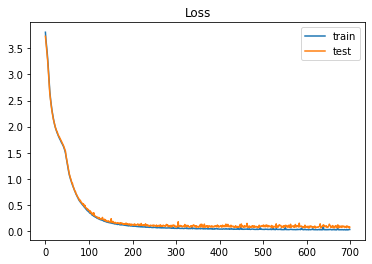

In [63]:
plt.plot(m.history['loss'], label='train')
plt.plot(m.history['val_loss'], label='test')
plt.legend()
plt.title("Loss")
plt.show()

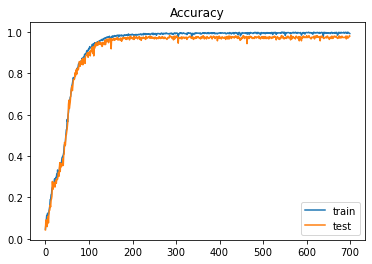

In [64]:
plt.plot(m.history['accuracy'], label='train')
plt.plot(m.history['val_accuracy'], label='test')
plt.legend()
plt.title("Accuracy")
plt.show()

In [82]:
loss_nn , accuracy = model.evaluate(x_test_np,y_test, verbose=0)
print(f'Loss : {loss}, Accuracy : {accuracy*100}%')

Loss : 0.0756471542472189, Accuracy : 97.95454740524292%


## Saving the model

In [18]:
import pickle

In [19]:
filename = 'Crop_Recommendation1.pkl'
pickle.dump(model, open(filename, 'wb'))

In [67]:
loaded_model = pickle.load(open(filename, 'rb'))
result = loaded_model.evaluate(x_test_np,y_test)
print(result)

440/440 [==============================] - 0s 331us/step
[0.11390562890605493, 0.9659090638160706]


## Trying with other models

### Random Forest Classifier

In [71]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(x_train_np, y_train)
accuracy_rfc = clf.score(x_test_np, y_test)
accuracy_rfc

0.825

### Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(x_test_np, y_test)
accuracy_logReg = log_reg.score(x_test_np, y_test)
accuracy_logReg

0.8

### Linear Regression

In [74]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_np, y_train)
accuracy_lr = lr.score(x_test_np, y_test)
accuracy_lr

0.4027552878506807

### Decision Tree Classifier

In [75]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=0)
dtc.fit(x_train_np, y_train)
accuracy_dtc = dtc.score(x_test_np, y_test)
accuracy_dtc

0.9636363636363636

## Evaluation

In [36]:
yp = model.predict(x_test_np)
len(yp)

440

In [52]:
y = []
def crop_name(val):
    for key, value in output.items():
         if val == value:
            y.append(key)
            return key
 
    return "key doesn't exist"

In [53]:
y_index = []
for i in yp :
    y_index.append(i.argmax())
    crop_name(i.argmax())
y

['banana',
 'jute',
 'papaya',
 'mungbean',
 'lentil',
 'papaya',
 'coffee',
 'papaya',
 'chickpea',
 'pigeonpeas',
 'mothbeans',
 'jute',
 'pomegranate',
 'mungbean',
 'maize',
 'mango',
 'lentil',
 'orange',
 'lentil',
 'lentil',
 'banana',
 'lentil',
 'blackgram',
 'coffee',
 'watermelon',
 'papaya',
 'mango',
 'orange',
 'jute',
 'muskmelon',
 'blackgram',
 'muskmelon',
 'pomegranate',
 'mango',
 'cotton',
 'orange',
 'chickpea',
 'pigeonpeas',
 'mungbean',
 'mango',
 'coffee',
 'cotton',
 'muskmelon',
 'blackgram',
 'chickpea',
 'muskmelon',
 'grapes',
 'mothbeans',
 'pigeonpeas',
 'papaya',
 'maize',
 'grapes',
 'papaya',
 'mango',
 'banana',
 'watermelon',
 'pigeonpeas',
 'muskmelon',
 'maize',
 'coconut',
 'mango',
 'muskmelon',
 'kidneybeans',
 'blackgram',
 'mango',
 'jute',
 'apple',
 'blackgram',
 'mothbeans',
 'kidneybeans',
 'maize',
 'pigeonpeas',
 'watermelon',
 'pomegranate',
 'watermelon',
 'cotton',
 'coffee',
 'apple',
 'watermelon',
 'cotton',
 'watermelon',
 'wate

In [55]:
from sklearn.metrics import confusion_matrix , classification_report

print(classification_report(y_test,y_index))

              precision    recall  f1-score   support

           1       0.74      0.94      0.83        18
           2       1.00      1.00      1.00        19
           3       1.00      1.00      1.00        18
           4       0.90      1.00      0.95        19
           5       1.00      0.91      0.95        22
           6       1.00      0.95      0.97        19
           7       1.00      1.00      1.00        20
           8       1.00      0.96      0.98        23
           9       0.89      1.00      0.94        16
          10       1.00      1.00      1.00        21
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        12
          14       1.00      1.00      1.00        21
          15       1.00      1.00      1.00        19
          16       1.00      1.00      1.00        25
          17       1.00      1.00      1.00        13
          18       1.00    

## Comparision

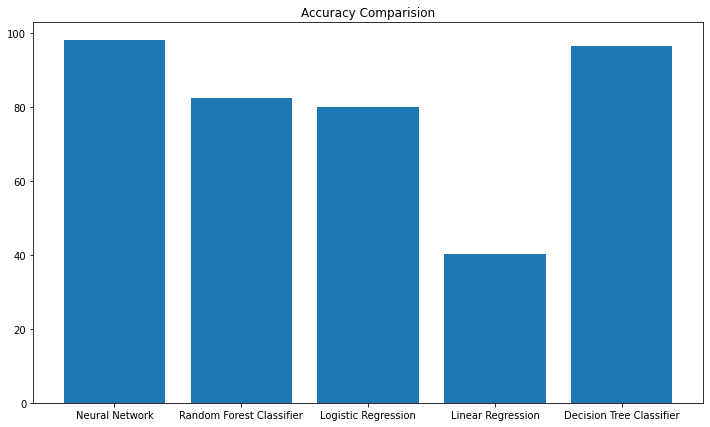

In [80]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array(["Neural Network", "Random Forest Classifier", "Logistic Regression", "Linear Regression", "Decision Tree Classifier"])
y = np.array([accuracy_nn*100, accuracy_rfc*100, accuracy_logReg*100, accuracy_lr*100, accuracy_dtc*100])
plt.figure(figsize = (12,7))
plt.title("Accuracy Comparision")
plt.bar(x,y)
plt.show()